In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
sales = pd.read_csv("StoreSales.csv")
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


In [20]:
store_detail = pd.read_csv("StoreDetail.csv")
store_detail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [21]:
products = pd.read_csv("Products.csv")
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


In [23]:
categories = pd.read_csv("ProductCategories.csv")
categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


In [24]:
customer = pd.read_csv("customer_list.csv", sep='|')
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


# Core marketing analysis 

In [27]:
## 1. Who are the territory managers for the sales territories assigned? What are the store IDs and cities
## for the stores in each assigned sales territory?

In [51]:
jensen_stores = store_detail[store_detail['Territory Manager'] == 'Len Jensen']
print(jensen_stores[['Store ID', 'Store Location', 'State', 'Territory Manager', 'Region']])

mask = store_detail['Territory Manager'] == 'Lana Ilana'
Ilana_stores = store_detail.loc[mask, ['Store ID', 'Store Location', 'State', 'Territory Manager', 'Region']]
print(Ilana_stores.head(2))

    Store ID Store Location           State Territory Manager Region
98       852     Charleston  South Carolina        Len Jensen  South
99       853     Greenville  South Carolina        Len Jensen  South
    Store ID   Store Location    State Territory Manager Region
26       719   Cape Canaveral  Florida        Lana Ilana  South
27       720  Fort Lauderdale  Florida        Lana Ilana  South


In [33]:
## 2. What is monthly total revenue for in-store sales in each of the two sales territories

In [74]:
print(sales.columns.tolist())

['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount', 'Store Location_x', 'State_x', 'Territory Manager_x', 'Region_x', 'Region Director_x', 'Store Location_y', 'State_y', 'Territory Manager_y', 'Region_y', 'Region Director_y', 'Store Location', 'State', 'Territory Manager', 'Region', 'Region Director']


In [82]:
monthly_revenue = (
    sales[
        (sales['State'] == 'South Carolina') |
        (sales['State'] == 'Florida') ]
    .groupby(['State', 'Store ID', 'Store Location'])['Sale Amount']
    .sum()
    .reset_index())


south_carolina = monthly_revenue[
    monthly_revenue['State'] == 'South Carolina']

florida = monthly_revenue[
    monthly_revenue['State'] == 'Florida'].head(2)

result = pd.concat([south_carolina, florida])
print(result)

             State  Store ID   Store Location  Sale Amount
11  South Carolina       852       Charleston    311810.56
12  South Carolina       853       Greenville    337002.00
0          Florida       719   Cape Canaveral    331956.13
1          Florida       720  Fort Lauderdale    302270.07


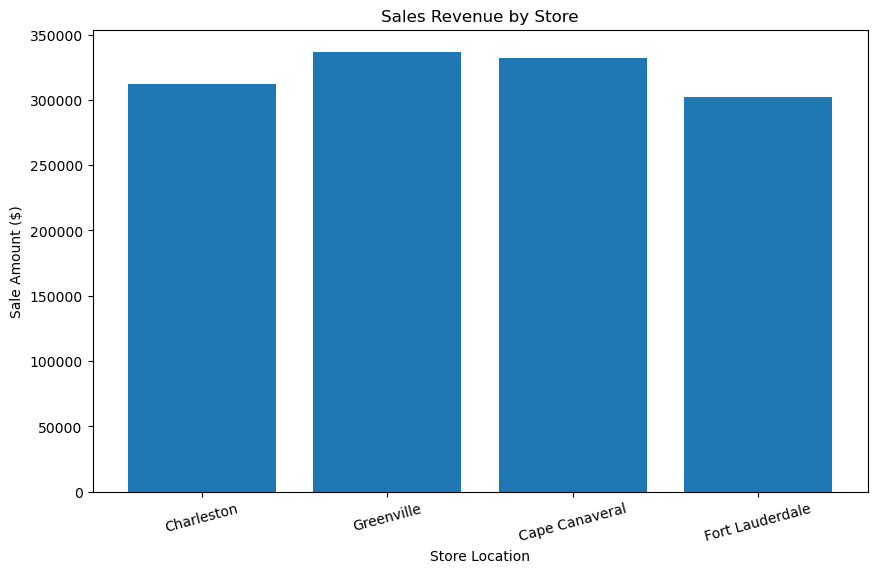

In [85]:
# South Carolina - 648,812.56
#Florida - 634,226.20

stores = [
    'Charleston',
    'Greenville',
    'Cape Canaveral',
    'Fort Lauderdale']

# Sales amounts

sales_amounts = [
    311810.56,
    337002.00,
    331956.13,
    302270.07]


plt.figure(figsize=(10,6))

plt.bar(stores, sales_amounts)

plt.title('Sales Revenue by Store')
plt.xlabel('Store Location')
plt.ylabel('Sale Amount ($)')

plt.xticks(rotation=15)
plt.show()

In [ ]:
## 4. Comparing the customer ID from the customer list data with the rewards ID from the sales data,
## who were the top customers in each sales territory

In [99]:
merged_customer = pd.merge(
    customer,
    sales,
    left_on='cust_id',
    right_on='RewardsID')

Jensen_customers = merged_customer[
    merged_customer['Store ID'].isin(jensen_stores['Store ID'])]

Ilana_customers = merged_customer[
    merged_customer['Store ID'].isin(Ilana_stores['Store ID'])]

Jensen_top = (
    Jensen_customers
    .groupby(['cust_id', 'name'])['Sale Amount']
    .sum()
    .reset_index()
    .sort_values('Sale Amount', ascending=False)
    .head(2))


Ilana_top = (
  Ilana_customers
    .groupby(['cust_id', 'name'])['Sale Amount']
    .sum()
    .reset_index()
    .sort_values('Sale Amount', ascending=False)
    .head(2))

print("Top 2 Customers - Len Jensen")
print(Jensen_top.to_string(index=False))

print("\nTop 2 Customers - Lana Ilana")
print(Ilana_top.to_string(index=False))

Top 2 Customers - Len Jensen
 cust_id      name  Sale Amount
     340  Jin Kwon      1786.05
     404 Roman Roy      1778.84

Top 2 Customers - Lana Ilana
 cust_id        name  Sale Amount
      47  Stanley H.      4954.99
     259 Todd Chavez      4549.16


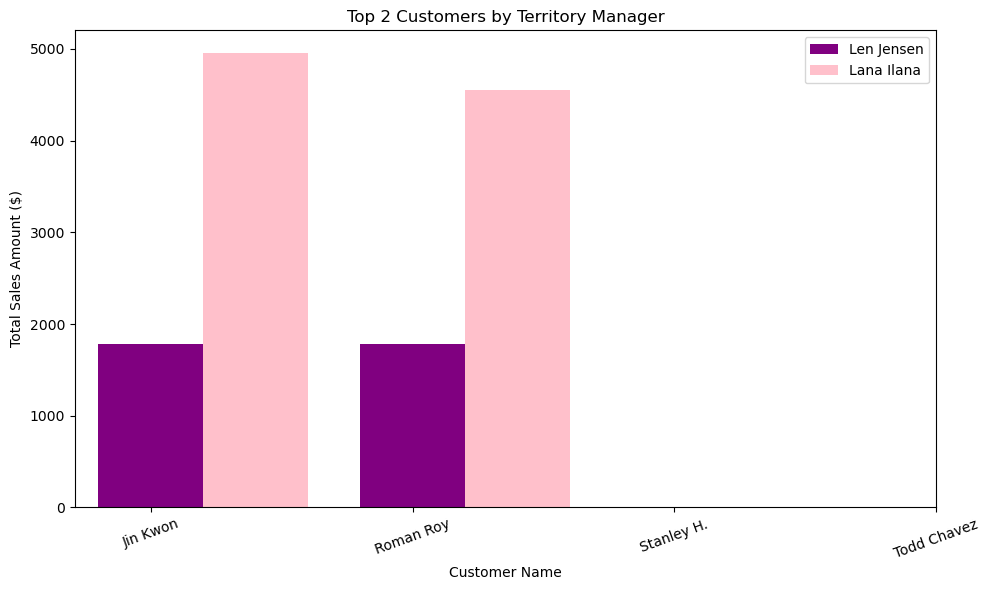

In [101]:
jensen_names = ['Jin Kwon', 'Roman Roy']
jensen_sales = [1786.05, 1778.84]

ilana_names = ['Stanley H.', 'Todd Chavez']
ilana_sales = [4954.99, 4549.16]

plt.figure(figsize=(10,6))

x1 = range(len(jensen_names))
x2 = range(len(ilana_names))

plt.bar(x1, jensen_sales, width=0.4, label='Len Jensen', color='purple')
plt.bar([i + 0.4 for i in x2], ilana_sales, width=0.4, label='Lana Ilana', color='pink')

plt.xticks(
    [0, 1, 2, 3],
    jensen_names + ilana_names,
    rotation=20)

plt.title('Top 2 Customers by Territory Manager')
plt.xlabel('Customer Name')
plt.ylabel('Total Sales Amount ($)')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
I think that my region is doing well for its size I do recommend trying to expand more in south Carolina trying to get more territoy 
but for what I compared we are doing better than the 2 stores compared in Florida with a higher revune for stores by 14,586.36 